In [ ]:
!pip install tensorflow
!pip install yfinance
!pip install scikit-learn
!pip install pandas
!pip install matplotlib


In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import yfinance as yf
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import datetime

# import to ignore warnings
import warnings
warnings.filterwarnings("ignore")


In [ ]:
import datetime
import yfinance as yf
# Choose a stock ticker symbol, e.g., 'AAPL' for Apple Inc.
ticker = 'AAPL'
# Download historical data from Yahoo Finance
data= yf.download(ticker, start='2020-01-01', end = datetime.datetime.today().strftime('%Y-%m-%d'))
# Focus on 'Close' prices for simplicity
data = data[['Close']]


[*********************100%***********************]  1 of 1 completed


In [ ]:
# Initialize MinMaxScaler to normalize the data between 0 and 1
scaler = MinMaxScaler(feature_range=(0,1))

# Scale the data for training
scaled_data = scaler.fit_transform(data)



In [ ]:
training_data_len=int(np.ceil(len(scaled_data)*0.8))

In [ ]:
x_train=[]
y_train=[]


In [ ]:
train_data = scaled_data[0:training_data_len, :]
for i in range(60, len(train_data)):
    x_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])

In [ ]:
x_train,y_train=np.array(x_train),np.array(y_train)

In [ ]:
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))


In [ ]:
model = Sequential()


In [ ]:
model.add(LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(Dropout(0.2))

In [ ]:
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))


In [ ]:
model.add(Dense(units=25))

In [ ]:
model.add(Dense(units=1))

In [ ]:
model.compile(optimizer='adam', loss='mean_squared_error')


In [ ]:
model.fit (x_train, y_train, batch_size=1, epochs=1)

2342/2342 ━━━━━━━━━━━━━━━━━━━━ 58s 24ms/step - loss: 0.0059


In [ ]:
last_60_days = scaled_data[-60:]
x_future = last_60_days.reshape((1, last_60_days.shape[0], 1))


In [ ]:
# Create an empty list to store predictions for the next 30 days
future_predictions = []
for _ in range(30):  # Change 30 to 60 to predict for 60 days
    # Predict the next day’s closing price based on the last 60 days
    pred = model.predict(x_future)
    future_predictions.append(pred[0, 0])  # Add prediction to the list

    # Update x_future with the new prediction by removing the first value and adding the new prediction
    x_future = np.append(x_future[:, 1:, :], [[pred[0]]], axis=1)



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━

In [ ]:
future_predictions = scaler.inverse_transform(np.array(future_predictions).reshape(-1, 1))


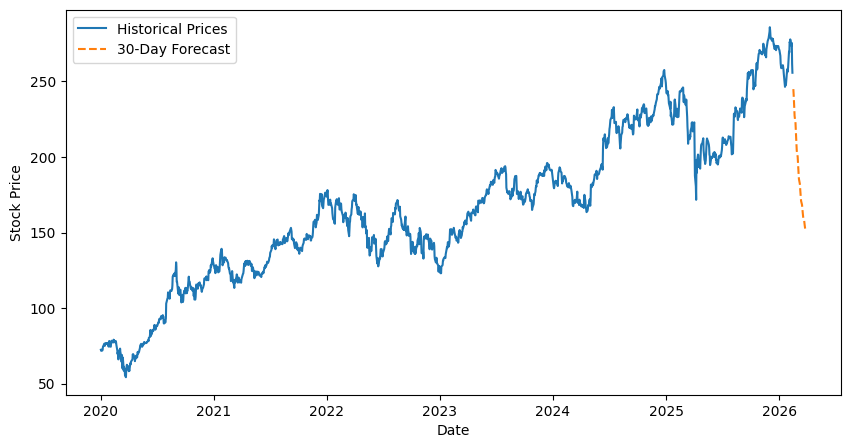

In [ ]:
# Create a DataFrame to hold the 30-day forecast with dates
forecast_dates = pd.date_range(start=data.index[-1] + pd.Timedelta(days=1), periods=30, freq='B')
forecast = pd.DataFrame(future_predictions, index=forecast_dates, columns=['Prediction'])

# Plot historical data and future predictions for comparison
plt.figure(figsize=(10, 5))
plt.plot(data['Close'], label='Historical Prices')
plt.plot(forecast, label='30-Day Forecast', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.show()
